# Continuation: ECG + FI-2010 Remaining Experiments

Both notebooks timed out. This single notebook completes what is missing.

**ECG completed**: Baselines, base RSNN, E1-E9. Missing: E10 (reduced-lead), E11 (class-wise temporal), confusion matrices.

**FI-2010 completed**: Baselines, base RSNN, F1-F4. Missing: F5 (hidden size), F6 (input BN), F7-F13 (analysis suite).

**Requires**: Attach ECG dataset (ptb-xl), FI-2010 dataset, and both NB outputs as datasets (for loading saved models).

**Estimated runtime**: ~6 hours on T4.

## 0. Setup + Model Definitions

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'snntorch', 'wfdb', '-q'])
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.7 MB/s eta 0:00:00
Done.


In [2]:
import os, glob, copy, time, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

SAVE_DIR = '/kaggle/working'
RESULTS_ECG = {}
RESULTS_FI = {}

Device: cuda


In [3]:
class SurrogateSpike(torch.autograd.Function):
    beta = 40.0
    @staticmethod
    def forward(ctx, mem, threshold=1.0):
        ctx.save_for_backward(mem)
        ctx.threshold = threshold
        return (mem >= threshold).float()
    @staticmethod
    def backward(ctx, grad_output):
        mem, = ctx.saved_tensors
        v = mem - ctx.threshold
        grad = 1.0 / (1.0 + SurrogateSpike.beta * torch.abs(v)) ** 2
        return grad_output * grad, None

def spike_fn(x, threshold=1.0):
    return SurrogateSpike.apply(x, threshold)

In [4]:
class SpikeEncoder:
    @staticmethod
    def direct(signal): return signal
    @staticmethod
    def delta_modulation(signal, threshold=0.1):
        T, C = signal.shape
        spikes = np.zeros_like(signal)
        reference = signal[0].copy()
        for t in range(1, T):
            diff = signal[t] - reference
            up = diff > threshold; down = diff < -threshold
            spikes[t, up] = 1.0; spikes[t, down] = -1.0
            reference[up] = signal[t, up]; reference[down] = signal[t, down]
        return spikes

In [5]:
class LIFLayer(nn.Module):
    def __init__(self, input_size, hidden_size, recurrent=False,
                 tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
                 learnable_tau=False, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.recurrent = recurrent
        self.dt = dt; self.dropout = dropout
        self.W_ff = nn.Linear(input_size, hidden_size, bias=False)
        if recurrent: self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        if learnable_tau:
            self.log_tau_mem = nn.Parameter(torch.tensor(np.log(tau_mem_init)))
            self.log_tau_syn = nn.Parameter(torch.tensor(np.log(tau_syn_init)))
        else:
            self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem_init)))
            self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn_init)))
        nn.init.kaiming_uniform_(self.W_ff.weight, nonlinearity='linear')
        if recurrent: nn.init.kaiming_uniform_(self.W_rec.weight, nonlinearity='linear')
    @property
    def alpha(self): return torch.exp(-self.dt / torch.exp(self.log_tau_syn))
    @property
    def beta(self): return torch.exp(-self.dt / torch.exp(self.log_tau_mem))
    def forward(self, x):
        B, T, _ = x.shape
        alpha, beta = self.alpha, self.beta
        syn = torch.zeros(B, self.hidden_size, device=x.device)
        mem = torch.zeros(B, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(B, self.hidden_size, device=x.device)
        spike_rec, mem_rec = [], []
        for t in range(T):
            syn = alpha * syn + self.W_ff(x[:, t])
            if self.recurrent:
                rec_spk = F.dropout(prev_spk, p=self.dropout, training=self.training) if self.dropout > 0 else prev_spk
                syn = syn + self.W_rec(rec_spk)
            mem = beta * mem * (1.0 - prev_spk) + (1.0 - beta) * syn
            spk = spike_fn(mem, threshold=1.0)
            spike_rec.append(spk); mem_rec.append(mem); prev_spk = spk
        return torch.stack(spike_rec, dim=1), torch.stack(mem_rec, dim=1)

In [6]:
class ReadoutLayer(nn.Module):
    def __init__(self, input_size, output_size, tau_mem=20.0, dt=10.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size, bias=False)
        self.beta = np.exp(-dt / tau_mem)
        nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='linear')
    def forward(self, x):
        B, T, _ = x.shape
        mem = torch.zeros(B, self.fc.out_features, device=x.device)
        mem_rec = []
        for t in range(T):
            mem = self.beta * mem + (1.0 - self.beta) * self.fc(x[:, t])
            mem_rec.append(mem)
        return torch.stack(mem_rec, dim=1)

class SNN(nn.Module):
    def __init__(self, input_size, hidden_size=256, output_size=5,
                 n_hidden_layers=1, recurrent=True, tau_mem=20.0, tau_syn=10.0,
                 dt=10.0, learnable_tau=False, loss_mode='max_over_time', dropout=0.0):
        super().__init__()
        self.loss_mode = loss_mode; self.hidden_size = hidden_size
        layers = []
        for i in range(n_hidden_layers):
            in_sz = input_size if i == 0 else hidden_size
            layers.append(LIFLayer(in_sz, hidden_size, recurrent, tau_mem, tau_syn, dt, learnable_tau, dropout))
        self.hidden_layers = nn.ModuleList(layers)
        self.readout = ReadoutLayer(hidden_size, output_size, tau_mem, dt)
    def forward(self, x):
        all_spikes = []; h = x
        for layer in self.hidden_layers:
            spikes, _ = layer(h); all_spikes.append(spikes); h = spikes
        out_mem = self.readout(h)
        if self.loss_mode == 'max_over_time': output, _ = torch.max(out_mem, dim=1)
        elif self.loss_mode == 'last_timestep': output = out_mem[:, -1, :]
        else: raise ValueError(self.loss_mode)
        return output, all_spikes, out_mem
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

class LSTMBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_layers=2, output_size=5, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x): out, _ = self.lstm(x); return self.fc(out[:, -1, :])
    def forward_seq(self, x): out, _ = self.lstm(x); return out
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

class CNNBaseline(nn.Module):
    def __init__(self, input_channels, output_size=5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 64, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(128, output_size)
    def forward(self, x): return self.fc(self.conv(x.transpose(1,2)).squeeze(-1))
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [7]:
def spike_regularization(all_spikes, theta_l=0.01, s_l=1.0, theta_u=100.0, s_u=0.06):
    reg = torch.tensor(0.0, device=all_spikes[0].device)
    for spk in all_spikes:
        B, T, N = spk.shape
        mean_rate = spk.sum(dim=1) / T
        reg += s_l / (B * N) * (F.relu(theta_l - mean_rate) ** 2).sum()
        pop_count = spk.sum(dim=(1, 2)) / N
        reg += s_u / B * (F.relu(pop_count - theta_u) ** 2).sum()
    return reg

def train_snn(model, train_ld, val_ld, test_ld, n_epochs=100, lr=1e-3,
              device='cuda', patience=20, verbose_every=10):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val, best_state, wait = 0, None, 0; t0 = time.time()
    for epoch in range(n_epochs):
        model.train(); tot_loss, correct, total = 0, 0, 0
        for x, y in train_ld:
            x, y = x.to(device), y.to(device)
            logits, spks, _ = model(x)
            loss = criterion(logits, y)
            if spks: loss += spike_regularization(spks)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
            tot_loss += loss.item()*len(y); correct += (logits.argmax(1)==y).sum().item(); total += len(y)
        val_acc = ev(model, val_ld, device, True)
        test_acc = ev(model, test_ld, device, True)
        if val_acc > best_val:
            best_val = val_acc; best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}; wait = 0
        else: wait += 1
        if epoch % verbose_every == 0 or epoch == n_epochs-1:
            m = '*' if wait==0 else ''
            print(f'  Ep {epoch:3d}: tr={correct/total:.4f} va={val_acc:.4f} te={test_acc:.4f} {m}')
        if wait >= patience: print(f'  Early stop ep {epoch}'); break
    if best_state: model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    final = ev(model, test_ld, device, True)
    print(f'  Final: {final*100:.2f}% ({time.time()-t0:.0f}s)'); return final, model

@torch.no_grad()
def ev(model, loader, device, is_snn=True):
    model.eval(); c, t = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_snn: logits, _, _ = model(x)
        else: logits = model(x)
        c += (logits.argmax(1)==y).sum().item(); t += len(y)
    return c/t

def train_baseline(model, tr, va, te, n_epochs=80, lr=1e-3, device='cuda', patience=20):
    model = model.to(device); opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(); best_val, best_state, wait = 0, None, 0; t0 = time.time()
    for ep in range(n_epochs):
        model.train()
        for x, y in tr: x, y = x.to(device), y.to(device); loss = crit(model(x), y); opt.zero_grad(); loss.backward(); opt.step()
        va_a = ev(model, va, device, False)
        if va_a > best_val: best_val=va_a; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else: wait += 1
        if ep % 20 == 0: print(f'  Ep {ep}: val={va_a:.4f}')
        if wait >= patience: print(f'  Early stop ep {ep}'); break
    if best_state: model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    final = ev(model, te, device, False); print(f'  Final: {final*100:.2f}% ({time.time()-t0:.0f}s)'); return final, model

---
# Part 1: ECG Remaining Experiments (E10, E11, Confusion Matrices)

Load ECG data and retrain base RSNN + LSTM (needed for analysis functions).

In [8]:
import wfdb, ast, pandas as pd

ecg_csv = glob.glob('/kaggle/input/**/ptbxl_database.csv', recursive=True)
assert ecg_csv, 'ECG dataset not found'
ECG_DIR = os.path.dirname(ecg_csv[0])
print(f'ECG_DIR: {ECG_DIR}')

df = pd.read_csv(os.path.join(ECG_DIR, 'ptbxl_database.csv'))
df.scp_codes = df.scp_codes.apply(ast.literal_eval)
scp_df = pd.read_csv(os.path.join(ECG_DIR, 'scp_statements.csv'), index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1.0]
SUPERCLASSES = ['NORM','MI','STTC','CD','HYP']
c2i = {c:i for i,c in enumerate(SUPERCLASSES)}
def get_sc(scp):
    best, lk = None, 0
    for k,v in scp.items():
        if k in scp_df.index:
            sc = scp_df.loc[k].diagnostic_class
            if sc in SUPERCLASSES and v > lk: best, lk = sc, v
    return best
df['sc'] = df.scp_codes.apply(get_sc)
df = df.dropna(subset=['sc'])
df['label'] = df.sc.map(c2i)
df_train = df[df.strat_fold <= 8]
df_val = df[df.strat_fold == 9]
df_test = df[df.strat_fold == 10]
def load_ecg(df_sub):
    sigs, labs = [], []
    for _, r in df_sub.iterrows():
        try:
            p = os.path.join(ECG_DIR, r['filename_lr'])
            if p.endswith('.hea'): p = p[:-4]
            sigs.append(wfdb.rdrecord(p).p_signal.astype(np.float32))
            labs.append(r['label'])
        except: pass
    return np.array(sigs), np.array(labs)
print('Loading ECG...')
X_tr_e, y_tr_e = load_ecg(df_train)
X_va_e, y_va_e = load_ecg(df_val)
X_te_e, y_te_e = load_ecg(df_test)
mu_e = X_tr_e.mean(axis=(0,1)); sd_e = X_tr_e.std(axis=(0,1))+1e-8
X_tr_e=(X_tr_e-mu_e)/sd_e; X_va_e=(X_va_e-mu_e)/sd_e; X_te_e=(X_te_e-mu_e)/sd_e
print(f'ECG loaded: tr={X_tr_e.shape}, va={X_va_e.shape}, te={X_te_e.shape}')

ECG_DIR: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
Loading ECG...
ECG loaded: tr=(17100, 1000, 12), va=(2155, 1000, 12), te=(2162, 1000, 12)


In [9]:
class ECGDataset(Dataset):
    def __init__(self, X, y, encoding='delta', n_bins=250, **kw):
        self.X, self.y = X, torch.tensor(y, dtype=torch.long)
        self.enc, self.n_bins, self.kw = encoding, n_bins, kw
        self.input_size = self._enc(X[0]).shape[1]
    def _enc(self, sig):
        idx = np.linspace(0, sig.shape[0]-1, self.n_bins).astype(int)
        s = sig[idx]
        if self.enc=='direct': return s
        elif self.enc=='delta': return SpikeEncoder.delta_modulation(s, **self.kw)
        return s
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.tensor(self._enc(self.X[i]), dtype=torch.float32), self.y[i]

N_BINS_E = 250; BS_E = 128; N_CLS_E = 5
# Base loaders
ecg_tr = DataLoader(ECGDataset(X_tr_e,y_tr_e,'delta',N_BINS_E,threshold=0.1), BS_E, True, num_workers=2)
ecg_va = DataLoader(ECGDataset(X_va_e,y_va_e,'delta',N_BINS_E,threshold=0.1), BS_E, False, num_workers=2)
ecg_te = DataLoader(ECGDataset(X_te_e,y_te_e,'delta',N_BINS_E,threshold=0.1), BS_E, False, num_workers=2)
ecg_tr_d = DataLoader(ECGDataset(X_tr_e,y_tr_e,'direct',N_BINS_E), BS_E, True, num_workers=2)
ecg_va_d = DataLoader(ECGDataset(X_va_e,y_va_e,'direct',N_BINS_E), BS_E, False, num_workers=2)
ecg_te_d = DataLoader(ECGDataset(X_te_e,y_te_e,'direct',N_BINS_E), BS_E, False, num_workers=2)
ECG_IN = ECGDataset(X_tr_e[:1],y_tr_e[:1],'delta',N_BINS_E,threshold=0.1).input_size
print(f'ECG input: {ECG_IN}')

ECG input: 12


### Retrain base RSNN + LSTM for ECG (needed for class-wise temporal + confusion)

In [10]:
print('--- ECG: RSNN base ---')
model_ecg = SNN(ECG_IN, 256, N_CLS_E, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
acc_ecg_rsnn, model_ecg = train_snn(model_ecg, ecg_tr, ecg_va, ecg_te)

print('\n--- ECG: LSTM ---')
model_ecg_lstm = LSTMBaseline(12, 128, 2, N_CLS_E, 0.3)
acc_ecg_lstm, model_ecg_lstm = train_baseline(model_ecg_lstm, ecg_tr_d, ecg_va_d, ecg_te_d)

--- ECG: RSNN base ---
  Ep   0: tr=0.4975 va=0.5360 te=0.5324 *
  Ep  10: tr=0.6233 va=0.5944 te=0.6087 
  Ep  20: tr=0.6342 va=0.6074 te=0.6189 
  Ep  30: tr=0.6360 va=0.6195 te=0.6142 
  Ep  40: tr=0.6400 va=0.6148 te=0.6286 
  Ep  50: tr=0.6463 va=0.6297 te=0.6253 *
  Ep  60: tr=0.6447 va=0.6213 te=0.6286 
  Ep  70: tr=0.6495 va=0.6278 te=0.6267 
  Early stop ep 78
  Final: 63.14% (5047s)

--- ECG: LSTM ---
  Ep 0: val=0.5100
  Ep 20: val=0.6515
  Ep 40: val=0.6872
  Early stop ep 57
  Final: 67.76% (219s)


### E10: Reduced-Lead Classification

In [11]:
print('='*60)
print('E10: REDUCED-LEAD CLASSIFICATION')
print('='*60)

lead_configs = {
    '1-lead (II)': [1],
    '3-lead (I,II,III)': [0, 1, 2],
    '6-lead (limb)': [0, 1, 2, 3, 4, 5],
}

for name, lead_idx in lead_configs.items():
    print(f'\n--- {name} ---')
    n_leads = len(lead_idx)
    X_tr_sub = X_tr_e[:, :, lead_idx]
    X_va_sub = X_va_e[:, :, lead_idx]
    X_te_sub = X_te_e[:, :, lead_idx]
    ds_tr = ECGDataset(X_tr_sub, y_tr_e, 'delta', N_BINS_E, threshold=0.1)
    ds_va = ECGDataset(X_va_sub, y_va_e, 'delta', N_BINS_E, threshold=0.1)
    ds_te = ECGDataset(X_te_sub, y_te_e, 'delta', N_BINS_E, threshold=0.1)
    ld_tr = DataLoader(ds_tr, BS_E, True, num_workers=2)
    ld_va = DataLoader(ds_va, BS_E, False, num_workers=2)
    ld_te = DataLoader(ds_te, BS_E, False, num_workers=2)
    inp = ds_tr.input_size
    m_r = SNN(inp, 256, N_CLS_E, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
    acc_r, _ = train_snn(m_r, ld_tr, ld_va, ld_te, n_epochs=80, patience=15)
    # LSTM on direct
    ds_tr_d = ECGDataset(X_tr_sub, y_tr_e, 'direct', N_BINS_E)
    ds_va_d = ECGDataset(X_va_sub, y_va_e, 'direct', N_BINS_E)
    ds_te_d = ECGDataset(X_te_sub, y_te_e, 'direct', N_BINS_E)
    ld_tr_d = DataLoader(ds_tr_d, BS_E, True, num_workers=2)
    ld_va_d = DataLoader(ds_va_d, BS_E, False, num_workers=2)
    ld_te_d = DataLoader(ds_te_d, BS_E, False, num_workers=2)
    m_l = LSTMBaseline(n_leads, 128, 2, N_CLS_E, 0.3)
    acc_l, _ = train_baseline(m_l, ld_tr_d, ld_va_d, ld_te_d)
    RESULTS_ECG[f'RSNN_{name}'] = acc_r
    RESULTS_ECG[f'LSTM_{name}'] = acc_l
    print(f'  RSNN: {acc_r*100:.2f}%, LSTM: {acc_l*100:.2f}%, gap: {(acc_r-acc_l)*100:+.2f}pp')

# 12-lead from base
RESULTS_ECG['RSNN_12-lead'] = acc_ecg_rsnn
RESULTS_ECG['LSTM_12-lead'] = acc_ecg_lstm
print(f'\n12-lead: RSNN={acc_ecg_rsnn*100:.2f}%, LSTM={acc_ecg_lstm*100:.2f}%')

E10: REDUCED-LEAD CLASSIFICATION

--- 1-lead (II) ---
  Ep   0: tr=0.4459 va=0.4534 te=0.4487 *
  Ep  10: tr=0.4743 va=0.4589 te=0.4718 
  Ep  20: tr=0.4744 va=0.4705 te=0.4727 
  Ep  30: tr=0.4771 va=0.4965 te=0.4746 *
  Ep  40: tr=0.4773 va=0.4882 te=0.4907 
  Early stop ep 45
  Final: 47.46% (2919s)
  Ep 0: val=0.4316
  Ep 20: val=0.5680
  Ep 40: val=0.5940
  Ep 60: val=0.5861
  Early stop ep 62
  Final: 59.25% (231s)
  RSNN: 47.46%, LSTM: 59.25%, gap: -11.79pp

--- 3-lead (I,II,III) ---
  Ep   0: tr=0.4680 va=0.5146 te=0.5120 *
  Ep  10: tr=0.5454 va=0.5258 te=0.5342 
  Ep  20: tr=0.5454 va=0.5318 te=0.5407 
  Ep  30: tr=0.5520 va=0.5411 te=0.5472 
  Early stop ep 30
  Final: 54.49% (1952s)
  Ep 0: val=0.4455
  Ep 20: val=0.6116
  Ep 40: val=0.6506
  Ep 60: val=0.6278
  Early stop ep 60
  Final: 63.27% (228s)
  RSNN: 54.49%, LSTM: 63.27%, gap: -8.79pp

--- 6-lead (limb) ---
  Ep   0: tr=0.4853 va=0.5072 te=0.4954 *
  Ep  10: tr=0.5516 va=0.5355 te=0.5458 
  Ep  20: tr=0.5370 va=0.5

### E11: Class-Wise Temporal Profile

E11: CLASS-WISE TEMPORAL


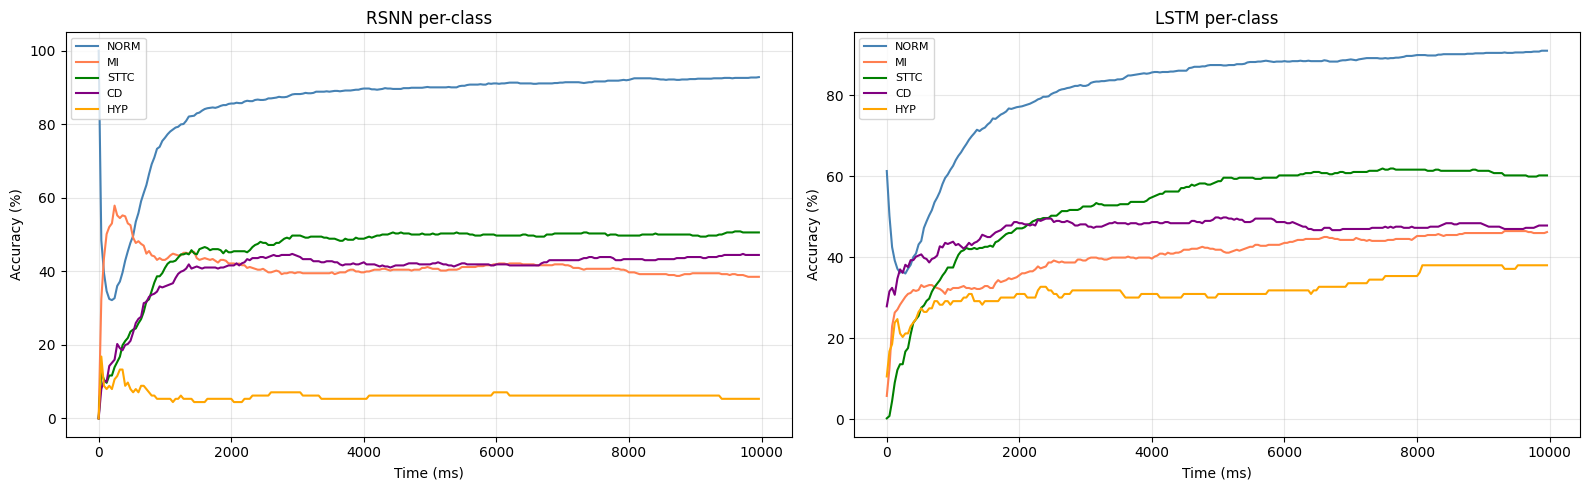

In [12]:
@torch.no_grad()
def classwise_temporal(model, loader, device, n_cls, is_lstm=False):
    model.eval()
    T_max = None; class_correct = None; class_total = np.zeros(n_cls)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_lstm: seq = model.fc(model.forward_seq(x))
        else: _, _, seq = model(x)
        B, T, C = seq.shape
        if T_max is None: T_max = T; class_correct = np.zeros((n_cls, T))
        rmax = torch.full((B, C), -float('inf'), device=device)
        for t in range(T):
            rmax = torch.max(rmax, seq[:, t])
            preds = rmax.argmax(1)
            for c in range(n_cls):
                mask = y == c
                if mask.sum() > 0:
                    class_correct[c, t] += (preds[mask]==c).float().sum().item()
        for c in range(n_cls): class_total[c] += (y==c).sum().item()
    for c in range(n_cls):
        if class_total[c] > 0: class_correct[c] /= class_total[c]
    return class_correct

print('='*60)
print('E11: CLASS-WISE TEMPORAL')
print('='*60)

rsnn_cw = classwise_temporal(model_ecg, ecg_te, device, N_CLS_E, False)
lstm_cw = classwise_temporal(model_ecg_lstm, ecg_te_d, device, N_CLS_E, True)

dt_ms = 40  # 10s / 250 steps
time_ms = np.arange(N_BINS_E) * dt_ms
colors = ['steelblue','coral','green','purple','orange']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for c in range(N_CLS_E):
    axes[0].plot(time_ms, rsnn_cw[c]*100, lw=1.5, color=colors[c], label=SUPERCLASSES[c])
    axes[1].plot(time_ms, lstm_cw[c]*100, lw=1.5, color=colors[c], label=SUPERCLASSES[c])
axes[0].set_title('RSNN per-class'); axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title('LSTM per-class'); axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR,'ecg_classwise.png'), dpi=150); plt.show()

### ECG Confusion Matrices

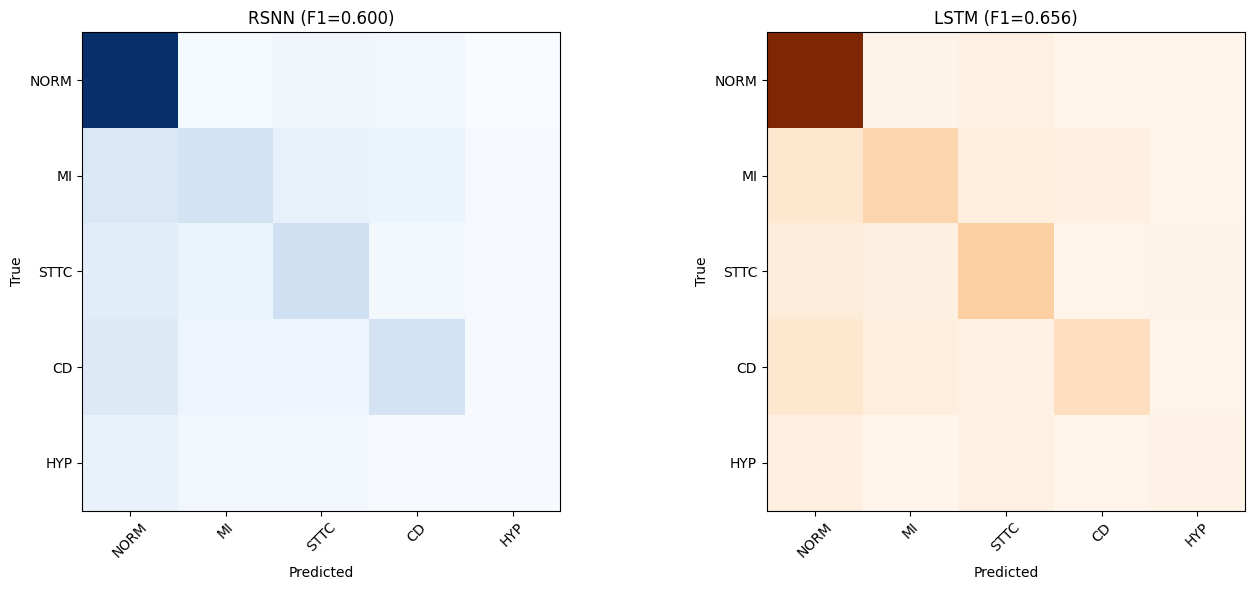

In [13]:
@torch.no_grad()
def get_preds(model, loader, device, is_snn=True):
    model.eval(); preds, labs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_snn: logits, _, _ = model(x)
        else: logits = model(x)
        preds.append(logits.argmax(1).cpu()); labs.append(y.cpu())
    return torch.cat(preds).numpy(), torch.cat(labs).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (model, loader, title, is_snn) in zip(axes, [
    (model_ecg, ecg_te, 'RSNN', True), (model_ecg_lstm, ecg_te_d, 'LSTM', False)]):
    p, l = get_preds(model, loader, device, is_snn)
    cm = confusion_matrix(l, p)
    ax.imshow(cm, cmap='Blues' if is_snn else 'Oranges')
    ax.set_xticks(range(N_CLS_E)); ax.set_yticks(range(N_CLS_E))
    ax.set_xticklabels(SUPERCLASSES, rotation=45); ax.set_yticklabels(SUPERCLASSES)
    ax.set_title(f'{title} (F1={f1_score(l,p,average="weighted"):.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR,'ecg_confusion.png'), dpi=150); plt.show()

---
# Part 2: FI-2010 Remaining Experiments (F5-F13)

In [14]:
import subprocess

# Download FI-2010 from DeepLOB repository
print("Downloading FI-2010 from DeepLOB repository...")
subprocess.run(['wget', '-q',
    'https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip',
    '-O', '/kaggle/working/data.zip'], check=True)
subprocess.run(['unzip', '-q', '-o', '/kaggle/working/data.zip', '-d', '/kaggle/working/'], check=True)
print("Downloaded.")

# Find the files
fi_train_file = glob.glob('/kaggle/working/**/Train_Dst_NoAuction_DecPre_CF_7.txt', recursive=True)
if not fi_train_file:
    # Also check BenchmarkDatasets subdirectory structure
    fi_train_file = glob.glob('/kaggle/working/**/Train_Dst_NoAuction*.txt', recursive=True)
assert fi_train_file, 'FI-2010 training file not found after download'
FI_DIR = os.path.dirname(fi_train_file[0])
print(f'FI_DIR: {FI_DIR}')

# Find test files
test_files = sorted(glob.glob(os.path.join(FI_DIR, 'Test_Dst_NoAuction*.txt')))
if not test_files:
    test_files = sorted(glob.glob('/kaggle/working/**/Test_Dst_NoAuction*.txt', recursive=True))
print(f'Train: {os.path.basename(fi_train_file[0])}')
print(f'Test files: {[os.path.basename(f) for f in test_files]}')

SEQ_LEN = 100; N_CLS_F = 3
def prep_x(d): return d[:40,:].T.astype(np.float32)
def get_lab(d): return (d[-5:,:].T.astype(int) - 1)
def make_seq(X, y, sl):
    n = len(X)-sl+1
    return np.array([X[i:i+sl] for i in range(n)]).astype(np.float32), y[sl-1:]

train_raw = np.loadtxt(fi_train_file[0])

# Use the last two test files (day 8 and day 9)
# The zip typically has Test_Dst_NoAuction_DecPre_CF_7.txt, _8.txt, _9.txt
test8_files = [f for f in test_files if '_8.txt' in f or '_CF_8' in f]
test9_files = [f for f in test_files if '_9.txt' in f or '_CF_9' in f]

if test9_files:
    test9_raw = np.loadtxt(test9_files[0])
elif len(test_files) >= 2:
    test9_raw = np.loadtxt(test_files[-1])  # last file as test
else:
    test9_raw = np.loadtxt(test_files[0])

X_full, y_full = make_seq(prep_x(train_raw), get_lab(train_raw)[:,0], SEQ_LEN)
vs = int(len(X_full)*0.8)
X_fi_tr, y_fi_tr = X_full[:vs], y_full[:vs]
X_fi_va, y_fi_va = X_full[vs:], y_full[vs:]
X_fi_te, y_fi_te = make_seq(prep_x(test9_raw), get_lab(test9_raw)[:,0], SEQ_LEN)
mu_f = X_fi_tr.mean(axis=(0,1)); sd_f = X_fi_tr.std(axis=(0,1))+1e-8
X_fi_tr=(X_fi_tr-mu_f)/sd_f; X_fi_va=(X_fi_va-mu_f)/sd_f; X_fi_te=(X_fi_te-mu_f)/sd_f
print(f'FI: tr={X_fi_tr.shape}, va={X_fi_va.shape}, te={X_fi_te.shape}')
print(f'Labels (test): {np.bincount(y_fi_te)}')

Downloaded.
FI_DIR: /kaggle/working
Train: Train_Dst_NoAuction_DecPre_CF_7.txt
Test files: ['Test_Dst_NoAuction_DecPre_CF_7.txt', 'Test_Dst_NoAuction_DecPre_CF_8.txt', 'Test_Dst_NoAuction_DecPre_CF_9.txt']
FI: tr=(203720, 100, 40), va=(50931, 100, 40), te=(31838, 100, 40)
Labels (test): [ 5510 21311  5017]


In [15]:
class LOBDataset(Dataset):
    def __init__(self, X, y, enc='direct', **kw):
        self.X, self.y = X, torch.tensor(y, dtype=torch.long)
        self.enc, self.kw = enc, kw
        self.input_size = self._enc(X[0]).shape[1]
    def _enc(self, s):
        if self.enc=='direct': return s
        return s
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.tensor(self._enc(self.X[i]), dtype=torch.float32), self.y[i]

BS_F = 256
fi_tr = DataLoader(LOBDataset(X_tr_f,y_tr_f), BS_F, True, num_workers=2)
fi_va = DataLoader(LOBDataset(X_va_f,y_va_f), BS_F, False, num_workers=2)
fi_te = DataLoader(LOBDataset(X_te_f,y_te_f), BS_F, False, num_workers=2)
print('FI-2010 loaders ready')

NameError: name 'X_tr_f' is not defined

### Retrain base RSNN + LSTM for FI-2010

In [ ]:
print('--- FI: RSNN base ---')
model_fi = SNN(40, 256, 3, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
acc_fi_rsnn, model_fi = train_snn(model_fi, fi_tr, fi_va, fi_te, n_epochs=80)

print('\n--- FI: LSTM ---')
model_fi_lstm = LSTMBaseline(40, 128, 2, 3, 0.3)
acc_fi_lstm, model_fi_lstm = train_baseline(model_fi_lstm, fi_tr, fi_va, fi_te)

### F5: Hidden Size Sweep

In [ ]:
print('='*60)
print('F5: HIDDEN SIZE SWEEP')
print('='*60)
for hs in [64, 128, 512]:
    print(f'\n--- hidden_size={hs} ---')
    m = SNN(40, hs, 3, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
    print(f'Params: {m.count_params():,}')
    acc, _ = train_snn(m, fi_tr, fi_va, fi_te, n_epochs=60, patience=15)
    RESULTS_FI[f'RSNN_h{hs}'] = acc

### F6: Input Batch Normalisation

In [ ]:
print('='*60)
print('F6: INPUT BATCH NORM')
print('='*60)

class SNN_BN(SNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.bn = nn.BatchNorm1d(self.hidden_layers[0].W_ff.in_features)
    def forward(self, x):
        B, T, C = x.shape
        x = self.bn(x.reshape(B*T, C)).reshape(B, T, C)
        return super().forward(x)

m_bn = SNN_BN(40, 256, 3, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
acc_bn, m_bn = train_snn(m_bn, fi_tr, fi_va, fi_te, n_epochs=80)
RESULTS_FI['RSNN_input_bn'] = acc_bn

### F7-F10: Analysis Suite (inference only)

In [ ]:
# F7: NOISE
print('='*60)
print('F7: NOISE ROBUSTNESS')
print('='*60)

@torch.no_grad()
def eval_noise(model, loader, device, sigma, is_snn=True):
    model.eval(); c, t = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        xn = x + sigma*torch.randn_like(x)
        if is_snn: logits, _, _ = model(xn)
        else: logits = model(xn)
        c += (logits.argmax(1)==y).sum().item(); t += len(y)
    return c/t

for s in [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    r = eval_noise(model_fi, fi_te, device, s, True)
    l = eval_noise(model_fi_lstm, fi_te, device, s, False)
    print(f'  sigma={s:.2f}: RSNN={r*100:.1f}% LSTM={l*100:.1f}% gap={100*(r-l):+.1f}pp')

In [ ]:
# F8: SPIKE EFFICIENCY
print('\n' + '='*60)
print('F8: SPIKE EFFICIENCY')
print('='*60)

@torch.no_grad()
def count_spikes(model, loader, device):
    model.eval(); counts = []
    for x, y in loader:
        x = x.to(device); _, spks, _ = model(x)
        batch_total = sum(s.sum(dim=(1,2)).cpu().numpy() for s in spks)
        counts.append(batch_total)
    return np.concatenate(counts)

sc = count_spikes(model_fi, fi_te, device)
rsnn_ops = sc.mean() * (256 + 3)
lstm_ops = (4*(40*128+128*128) + 4*(128*128+128*128)) * SEQ_LEN
print(f'RSNN: mean {sc.mean():.0f} spikes, {rsnn_ops:,.0f} ops')
print(f'LSTM: {lstm_ops:,.0f} ops ({lstm_ops/max(rsnn_ops,1):.1f}x more)')

In [ ]:
# F9: RECURRENCE ABLATION
print('\n' + '='*60)
print('F9: RECURRENCE ABLATION')
print('='*60)
model_abl = copy.deepcopy(model_fi)
with torch.no_grad():
    for layer in model_abl.hidden_layers:
        if hasattr(layer, 'W_rec'): layer.W_rec.weight.data.zero_()
acc_abl = ev(model_abl, fi_te, device, True)
print(f'With recurrence:    {acc_fi_rsnn*100:.2f}%')
print(f'Without:            {acc_abl*100:.2f}%')
print(f'Drop: {(acc_fi_rsnn-acc_abl)*100:.2f}pp')

In [ ]:
# F10: EARLY CLASSIFICATION
print('\n' + '='*60)
print('F10: EARLY CLASSIFICATION')
print('='*60)

@torch.no_grad()
def early_class(model, loader, device, is_lstm=False):
    model.eval(); all_fc, all_lab = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device); B = x.shape[0]
        if is_lstm: lseq = model.fc(model.forward_seq(x))
        else: _, _, lseq = model(x)
        _, T, C = lseq.shape
        rmax = torch.full((B, C), -float('inf'), device=device)
        fc = torch.full((B,), -1, dtype=torch.long, device=device)
        for t in range(T):
            rmax = torch.max(rmax, lseq[:, t])
            newly = (rmax.argmax(1) == y) & (fc == -1); fc[newly] = t
        all_fc.append(fc.cpu()); all_lab.append(y.cpu())
    return torch.cat(all_fc).numpy(), torch.cat(all_lab).numpy()

rfc, labels = early_class(model_fi, fi_te, device, False)
lfc, _ = early_class(model_fi_lstm, fi_te, device, True)
for c, nm in enumerate(['Down','Stationary','Up']):
    m = labels == c
    rv = rfc[m][rfc[m]>=0]; lv = lfc[m][lfc[m]>=0]
    rm = np.median(rv) if len(rv)>0 else float('inf')
    lm = np.median(lv) if len(lv)>0 else float('inf')
    print(f'  {nm:>12}: RSNN med={rm:.0f}steps, LSTM med={lm:.0f}steps')

### F11: Multi-Horizon

In [ ]:
print('='*60)
print('F11: MULTI-HORIZON')
print('='*60)

HORIZONS = {0:'k=10', 2:'k=30', 4:'k=100'}
for h_idx, h_name in HORIZONS.items():
    print(f'\n--- {h_name} ---')
    _, y_full_h = make_seq(prep_x(train_raw), get_lab(train_raw)[:,h_idx], SEQ_LEN)
    y_tr_h = y_full_h[:val_split]; y_va_h = y_full_h[val_split:]
    _, y_te_h = make_seq(prep_x(test9_raw), get_lab(test9_raw)[:,h_idx], SEQ_LEN)
    ds_tr = LOBDataset(X_tr_f, y_tr_h); ds_va = LOBDataset(X_va_f, y_va_h); ds_te = LOBDataset(X_te_f, y_te_h)
    ld_tr = DataLoader(ds_tr, BS_F, True, num_workers=2)
    ld_va = DataLoader(ds_va, BS_F, False, num_workers=2)
    ld_te = DataLoader(ds_te, BS_F, False, num_workers=2)
    m_r = SNN(40, 256, 3, 1, True, 20.0, 10.0, 10.0, True, 'max_over_time', 0.3)
    acc_r, _ = train_snn(m_r, ld_tr, ld_va, ld_te, n_epochs=60, patience=15)
    m_l = LSTMBaseline(40, 128, 2, 3, 0.3)
    acc_l, _ = train_baseline(m_l, ld_tr, ld_va, ld_te)
    RESULTS_FI[f'RSNN_{h_name}'] = acc_r; RESULTS_FI[f'LSTM_{h_name}'] = acc_l
    print(f'  RSNN: {acc_r*100:.2f}%, LSTM: {acc_l*100:.2f}%')

### F12: Price vs Volume

In [ ]:
print('='*60)
print('F12: PRICE vs VOLUME')
print('='*60)
print(f'Baseline: {acc_fi_rsnn*100:.2f}%')

@torch.no_grad()
def eval_zeroed(model, loader, device, zero_idx):
    model.eval(); c, t = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        xz = x.clone(); xz[:,:,zero_idx] = 0.0
        logits, _, _ = model(xz)
        c += (logits.argmax(1)==y).sum().item(); t += len(y)
    return c/t

price_idx = list(range(0,40,2))
vol_idx = list(range(1,40,2))
acc_no_p = eval_zeroed(model_fi, fi_te, device, price_idx)
acc_no_v = eval_zeroed(model_fi, fi_te, device, vol_idx)
print(f'Prices zeroed: {acc_no_p*100:.2f}% (drop: {(acc_fi_rsnn-acc_no_p)*100:.2f}pp)')
print(f'Volumes zeroed: {acc_no_v*100:.2f}% (drop: {(acc_fi_rsnn-acc_no_v)*100:.2f}pp)')

### F13: Per-Level Importance

In [ ]:
print('='*60)
print('F13: PER-LEVEL')
print('='*60)
for n_lev in [1, 2, 5, 10]:
    zero_idx = list(range(n_lev * 4))
    acc = eval_zeroed(model_fi, fi_te, device, zero_idx)
    print(f'  Levels 1-{n_lev} zeroed: {acc*100:.2f}% (drop: {(acc_fi_rsnn-acc)*100:.2f}pp)')

### FI-2010 Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
FI_NAMES = ['Down','Stat','Up']
for ax, (model, loader, title, is_snn) in zip(axes, [
    (model_fi, fi_te, 'RSNN', True), (model_fi_lstm, fi_te, 'LSTM', False)]):
    p, l = get_preds(model, loader, device, is_snn)
    cm = confusion_matrix(l, p)
    ax.imshow(cm, cmap='Blues' if is_snn else 'Oranges')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(FI_NAMES); ax.set_yticklabels(FI_NAMES)
    ax.set_title(f'{title} (F1={f1_score(l,p,average="weighted"):.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR,'fi_confusion.png'), dpi=150); plt.show()

---
## Final Summary

In [ ]:
print('='*70)
print('ALL REMAINING EXPERIMENTS COMPLETE')
print('='*70)

print('\n--- ECG New Results ---')
for k,v in sorted(RESULTS_ECG.items(), key=lambda x:x[1], reverse=True):
    print(f'  {k:30s} {v*100:7.2f}%')

print('\n--- FI-2010 New Results ---')
for k,v in sorted(RESULTS_FI.items(), key=lambda x:x[1], reverse=True):
    print(f'  {k:30s} {v*100:7.2f}%')

all_results = {'ecg_continuation': RESULTS_ECG, 'fi2010_continuation': RESULTS_FI}
with open(os.path.join(SAVE_DIR, 'continuation_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2, default=str)
print('\nSaved continuation_results.json')